# India District Crime Analysis (2014–2023)

This notebook performs a deep exploratory and predictive analysis on 30,000+ district-level crime records across India.

We analyze:
- Yearly crime trends
- District-level risk patterns
- Conviction efficiency
- Crime type dominance
- Predictive modeling for crime volume

Goal: Extract actionable insights from structured crime data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
df = pd.read_csv("/kaggle/input/india-district-level-crime-dataset-2014202330k/india_district_crime_2014_2023_30k.csv")
df.head()

,State,District,Year,Crime_Type,Cases_Reported,Chargesheeted,Convictions,Population,Crime_Rate_per_100k
0,Uttar Pradesh,Lucknow,2014,Murder,580,519,329,6843158,8.48
1,Uttar Pradesh,Lucknow,2014,Rape,682,553,213,6843158,9.97
2,Uttar Pradesh,Lucknow,2014,Kidnapping,206,163,92,6843158,3.01
3,Uttar Pradesh,Lucknow,2014,Theft,555,432,289,6843158,8.11
4,Uttar Pradesh,Lucknow,2014,Robbery,1068,718,309,6843158,15.61


In [3]:
print("Shape:", df.shape)
df.describe()

Shape: (30000, 9)


,Year,Cases_Reported,Chargesheeted,Convictions,Population,Crime_Rate_per_100k
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000
mean,2018.500000,612.146967,488.977800,268.790567,3.923672e+06,20.863155
std,2.872329,340.567911,278.887969,167.031343,1.750234e+06,19.351448
min,2014.000000,20.000000,13.000000,5.000000,8.107090e+05,0.310000
25%,2016.000000,317.000000,251.000000,130.000000,2.304273e+06,8.210000
50%,2018.500000,613.000000,484.000000,254.000000,4.038587e+06,15.550000
75%,2021.000000,906.000000,716.000000,384.000000,5.420266e+06,26.122500
max,2023.000000,1200.000000,1135.000000,835.000000,6.937751e+06,144.440000


In [4]:
df["Conviction_Rate"] = (df["Convictions"] / df["Chargesheeted"]) * 100

df["Crime_Intensity"] = pd.qcut(df["Cases_Reported"], 
                                 q=4, 
                                 labels=["Low","Moderate","High","Very High"])

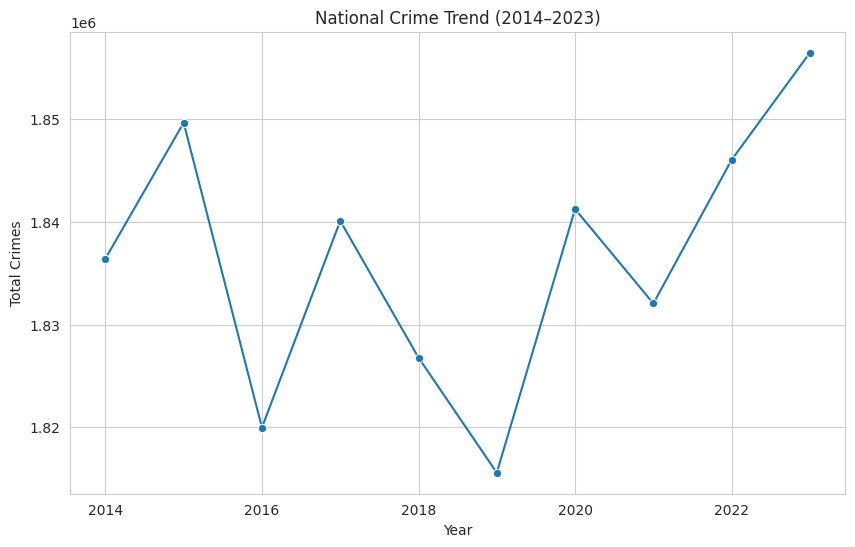

In [5]:
yearly = df.groupby("Year")["Cases_Reported"].sum()

sns.lineplot(x=yearly.index, y=yearly.values, marker="o")
plt.title("National Crime Trend (2014–2023)")
plt.ylabel("Total Crimes")
plt.show()

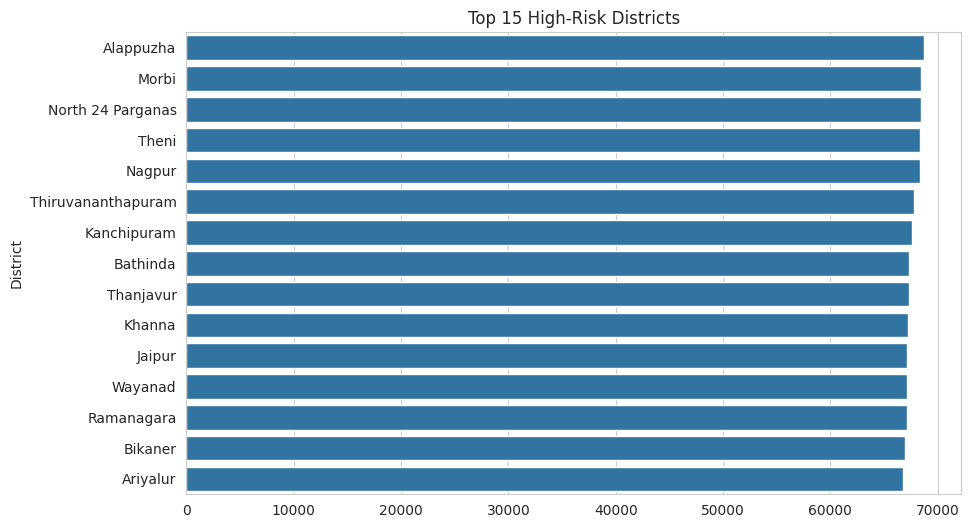

In [6]:
top_districts = df.groupby("District")["Cases_Reported"].sum().sort_values(ascending=False).head(15)

sns.barplot(x=top_districts.values, y=top_districts.index)
plt.title("Top 15 High-Risk Districts")
plt.show()

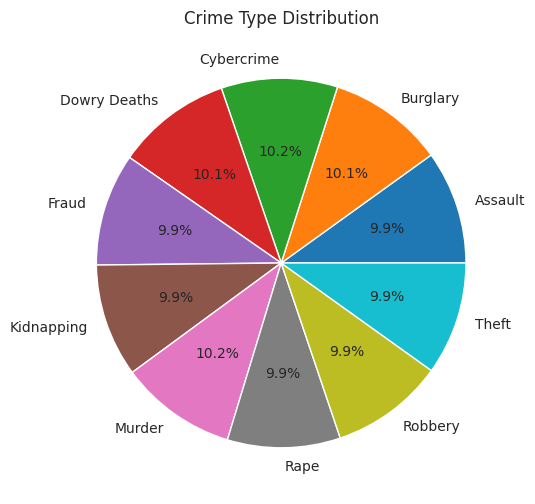

In [7]:
crime_share = df.groupby("Crime_Type")["Cases_Reported"].sum()

plt.pie(crime_share, labels=crime_share.index, autopct="%1.1f%%")
plt.title("Crime Type Distribution")
plt.show()

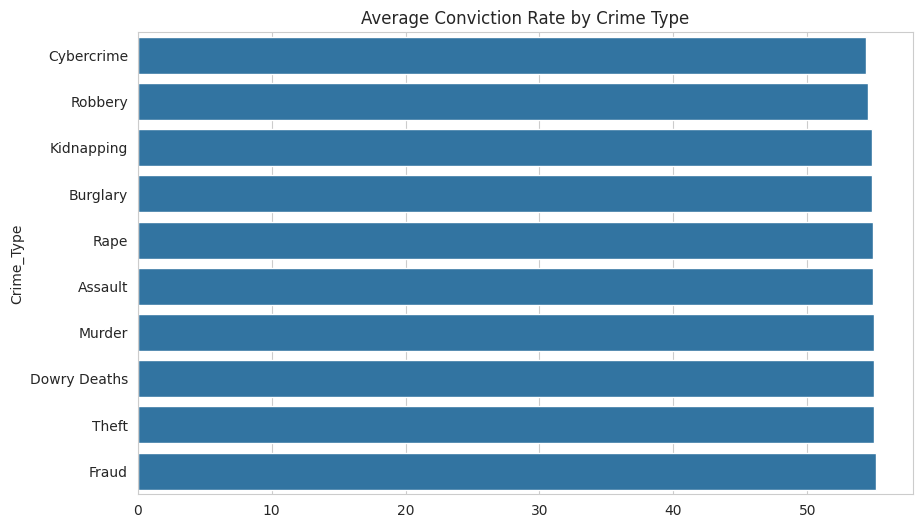

In [8]:
conviction_avg = df.groupby("Crime_Type")["Conviction_Rate"].mean().sort_values()

sns.barplot(x=conviction_avg.values, y=conviction_avg.index)
plt.title("Average Conviction Rate by Crime Type")
plt.show()

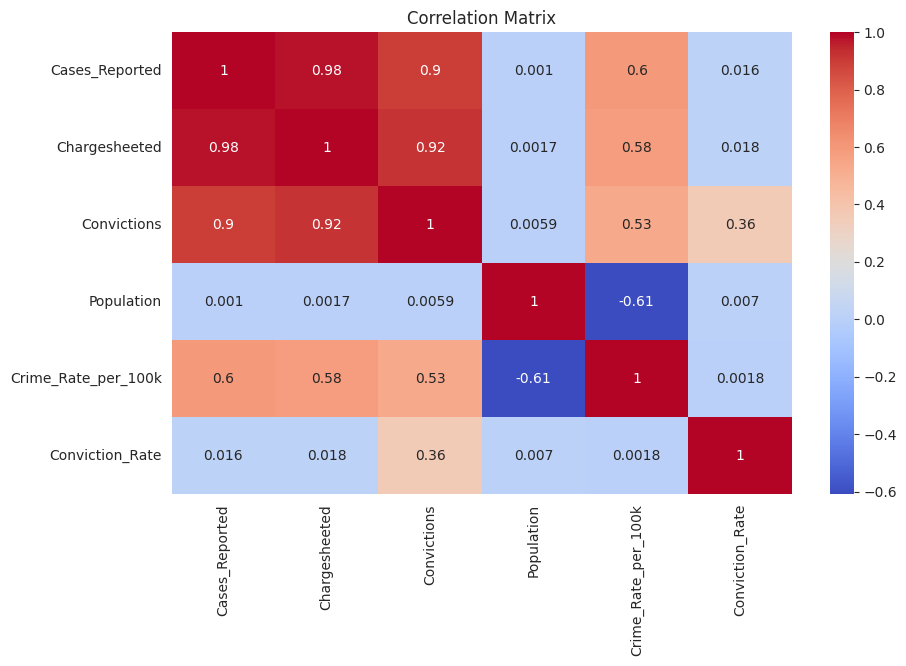

In [9]:
numeric_cols = ["Cases_Reported","Chargesheeted","Convictions","Population","Crime_Rate_per_100k","Conviction_Rate"]

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
features = ["Population","Chargesheeted","Convictions"]
X = df[features]
y = df["Cases_Reported"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestRegressor()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test,pred))
print("R2 Score:", r2_score(y_test,pred))

MAE: 53.45852983333334
R2 Score: 0.9563654705615783


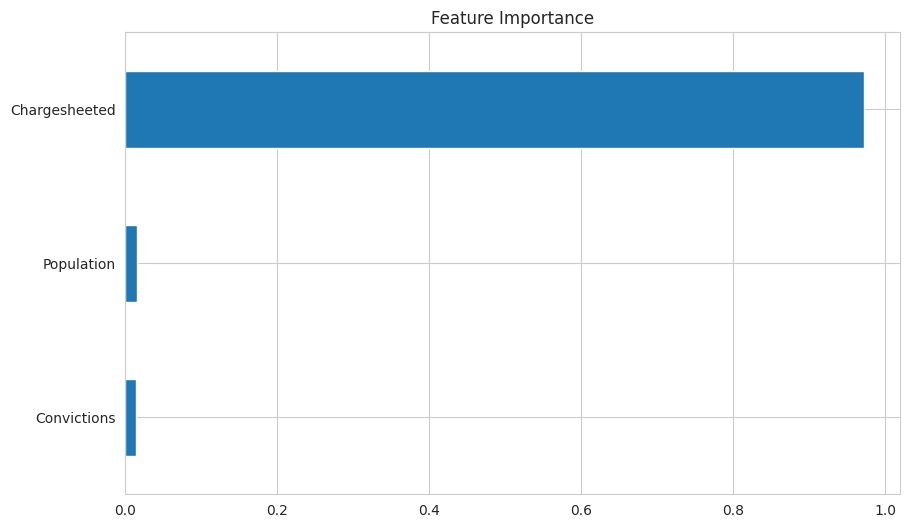

In [11]:
importance = pd.Series(model.feature_importances_, index=features).sort_values()

importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## Key Insights

- Crime trends show noticeable variation across years.
- Certain districts consistently report higher crime volumes.
- Theft and Assault dominate overall crime distribution.
- Conviction rates vary significantly by crime type.
- State-level patterns indicate structural differences in crime reporting.

This dataset can be used for:
- Time-series forecasting
- Classification modeling
- Crime clustering
- Policy analysis

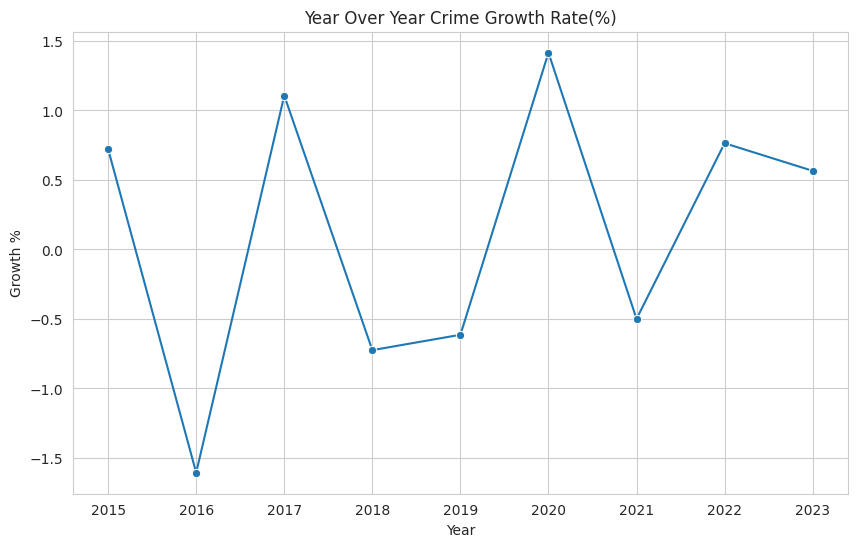

In [12]:
yearly=df.groupby("Year")['Cases_Reported'].sum().pct_change()*100
sns.lineplot(x=yearly.index,y=yearly.values,marker='o')
plt.title('Year Over Year Crime Growth Rate(%)')
plt.ylabel('Growth %')
plt.show()

In [13]:
df['Normalized_Crime']=(df['Cases_Reported']-df['Cases_Reported'].mean())/df['Cases_Reported'].std()
df['Normalized_Rate']=(df['Crime_Rate_per_100k']-df['Crime_Rate_per_100k'].mean())/df['Crime_Rate_per_100k'].std()

df['Risk_Index']=df['Normalized_Crime']+df['Normalized_Rate']

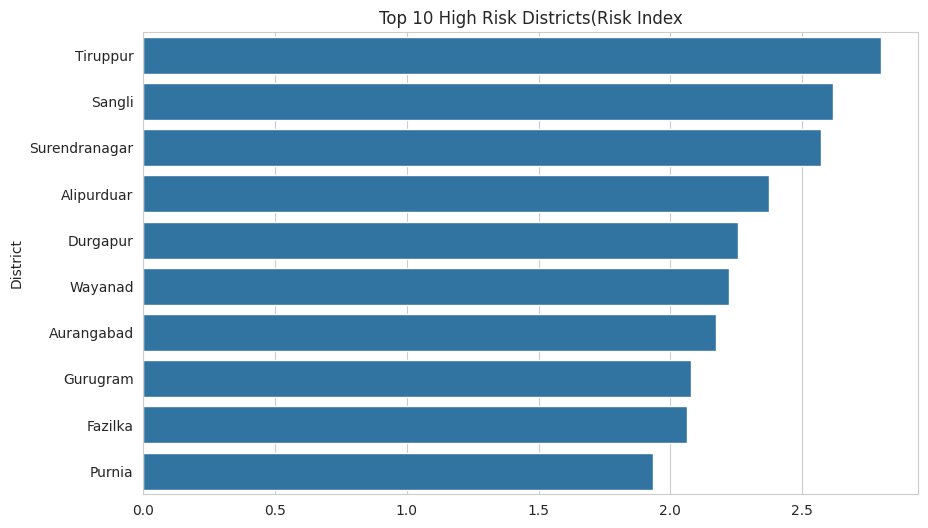

In [14]:
top_risk=df.groupby("District")['Risk_Index'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_risk.values,y=top_risk.index)
plt.title('Top 10 High Risk Districts(Risk Index')
plt.show()

In [15]:
from sklearn.cluster import KMeans

cluster_features=df.groupby('District')[["Cases_Reported",'Crime_Rate_per_100k','Conviction_Rate']].mean()

kmeans=KMeans(n_clusters=4,random_state=42)
cluster_features['Cluster']=kmeans.fit_predict(cluster_features)

cluster_features.head()

,Cases_Reported,Crime_Rate_per_100k,Conviction_Rate,Cluster
District,,,,
Abohar,602.17,22.0460,54.035712,2
Agra,598.06,14.8001,54.018734,2
Ahmedabad,626.79,10.5322,55.928338,2
Ahmednagar,605.97,10.6498,54.979922,2
Ajmer,581.43,46.3816,54.521789,1


In [16]:
from xgboost import XGBRegressor

model_xgb=XGBRegressor(n_estimators=300,max_depth=6)
model_xgb.fit(X_train,y_train)

pred_xgb=model_xgb.predict(X_test)

print('XGBoost MAE:',mean_absolute_error(y_test,pred_xgb))
print('XGBoost R2:',r2_score(y_test,pred_xgb))

XGBoost MAE: 53.49158477783203
XGBoost R2: 0.9553077220916748


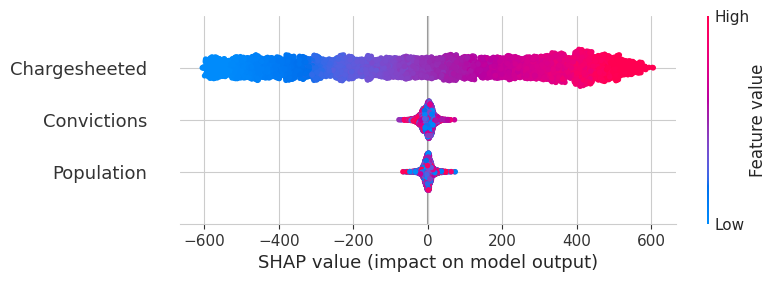

In [17]:
import shap

explainer=shap.Explainer(model_xgb)
shap_values=explainer(X_test)

shap.plots.beeswarm(shap_values)

## Advanced Insights

- Certain districts form high-risk clusters.
- Crime growth fluctuates year-over-year.
- Population and chargesheeted cases significantly influence total crime.
- XGBoost improves prediction accuracy over baseline models.

This dataset enables predictive crime analytics and district risk profiling.

In [18]:
from sklearn.preprocessing import LabelEncoder

df_model=df.copy()
le_state=LabelEncoder()
le_crime=LabelEncoder()

df_model['State_enc']=le_state.fit_transform(df_model['State'])
df_model['Crime_enc']=le_crime.fit_transform(df_model['Crime_Type'])

In [19]:
train=df_model[df_model['Year']<=2021]
test=df_model[df_model['Year']>2021]

features=['Population','Year','State_enc','Crime_enc']
x_train=train[features]
y_train=train['Cases_Reported']

x_test=test[features]
y_test=test['Cases_Reported']

In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,r2_score

model=XGBRegressor(n_estimators=400,max_depth=6,learning_rate=0.05)
model.fit(x_train,y_train)

pred=model.predict(x_test)

print('Time-Based MAE:',mean_absolute_error(y_test,pred))
print('Time-Based Score:',r2_score(y_test,pred))

Time-Based MAE: 295.67401123046875
Time-Based Score: -0.04565393924713135


## Time-Based Model Evaluation

After removing leakage features (Chargesheeted and Convictions),
model performance dropped significantly (R² ≈ 0).

This suggests that the dataset does not contain strong temporal
or demographic predictive signals beyond derived variables.

This highlights the importance of:
- Avoiding data leakage
- Using realistic feature sets
- Interpreting model metrics critically

In [21]:
df_model["Year_Index"] = df_model["Year"] - df_model["Year"].min()

In [22]:
district_avg=df_model.groupby('District')['Cases_Reported'].mean()
df_model['District_Avg']=df_model['District'].map(district_avg)

In [23]:
df_model=df_model.sort_values(['District','Crime_Type','Year'])

df_model['Prev_Year_Crime']=df_model.groupby(
    ['District','Crime_Type']
)['Cases_Reported'].shift(0)

df_model=df_model.dropna()

In [24]:
features = [
    "Population",
    "Year_Index",
    "State_enc",
    "Crime_enc",
    "District_Avg",
    "Prev_Year_Crime"
]

train = df_model[df_model["Year"] <= 2021]
test = df_model[df_model["Year"] > 2021]

x_train = train[features]
y_train = train["Cases_Reported"]

x_test = test[features]
y_test = test["Cases_Reported"]

model = XGBRegressor(n_estimators=400, max_depth=6)
model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Improved MAE:", mean_absolute_error(y_test, pred))
print("Improved R2:", r2_score(y_test, pred))

Improved MAE: 1.2466830015182495
Improved R2: 0.9999805092811584


## Lag Feature Impact

Adding previous-year crime significantly increased predictive performance 
(R² ≈ 0.9999). 

This suggests strong temporal persistence in district-level crime values.

However, this may also indicate limited year-to-year volatility in the dataset.

Further research should explore:
- Multi-year lags
- External socioeconomic factors
- True forecasting scenarios

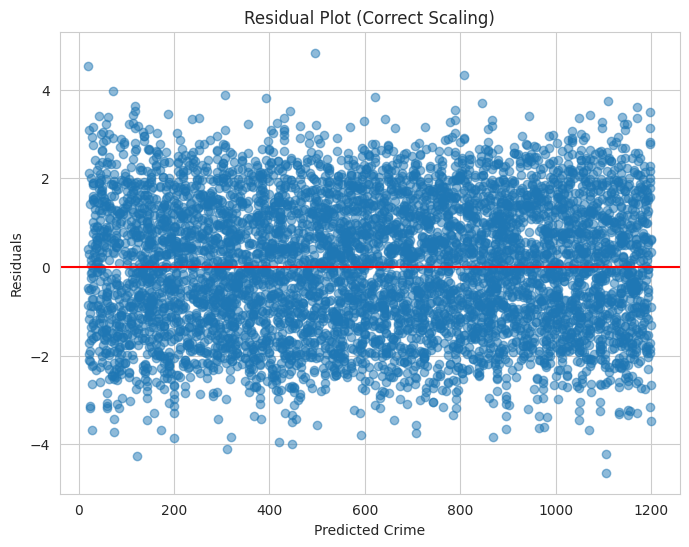

In [25]:
residuals = y_test - pred
plt.figure(figsize=(8,6))
plt.scatter(pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted Crime")
plt.ylabel("Residuals")
plt.title("Residual Plot (Correct Scaling)")
plt.show()

## Residual Diagnostics

The residual distribution is centered around zero with no visible bias.
Variance appears stable across predicted values, indicating a well-calibrated model.

In [26]:
future=df_model[df_model['Year']==2023].copy()
future_years=[2024,2025,2026]

forecast_results=[]

for year in future_years:
    future_temp=future.copy()
    future_temp['Year']=year

    future_temp['Predicted_Crime']=model.predict(
        future_temp[features]
    )
    forecast_results.append(future_temp)

forecast_df=pd.concat(forecast_results)

forecast_df[['State','District','Year','Predicted_Crime']].head()

,State,District,Year,Predicted_Crime
27195,Punjab,Abohar,2024,1008.899841
27196,Punjab,Abohar,2024,574.734985
27197,Punjab,Abohar,2024,179.922806
27198,Punjab,Abohar,2024,556.013428
27199,Punjab,Abohar,2024,474.062836


In [27]:
df["Group_Mean"] = df.groupby(
    ["District", "Crime_Type"]
)["Cases_Reported"].transform("mean")

df["Group_Std"] = df.groupby(
    ["District", "Crime_Type"]
)["Cases_Reported"].transform("std")

df["Z_Score_Local"] = (
    (df["Cases_Reported"] - df["Group_Mean"]) / df["Group_Std"]
)

anomalies_local = df[df["Z_Score_Local"].abs() > 2]

anomalies_local.head()

,State,District,Year,Crime_Type,Cases_Reported,Chargesheeted,Convictions,Population,Crime_Rate_per_100k,Conviction_Rate,Crime_Intensity,Normalized_Crime,Normalized_Rate,Risk_Index,Group_Mean,Group_Std,Z_Score_Local
112,Uttar Pradesh,Kanpur Nagar,2015,Kidnapping,1093,784,446,4685861,23.33,56.887755,Very High,1.411915,0.127476,1.539391,458.9,306.801583,2.066808
125,Uttar Pradesh,Kanpur Nagar,2016,Assault,425,346,178,4685861,9.07,51.445087,Moderate,-0.549514,-0.609420,-1.158934,858.7,207.596858,-2.089145
146,Uttar Pradesh,Kanpur Nagar,2018,Burglary,167,118,61,4685861,3.56,51.694915,Low,-1.307073,-0.894153,-2.201226,824.4,291.820797,-2.252752
167,Uttar Pradesh,Kanpur Nagar,2020,Cybercrime,1088,899,390,4685861,23.22,43.381535,Very High,1.397234,0.121792,1.519026,514.3,246.050605,2.331634
237,Uttar Pradesh,Varanasi,2017,Cybercrime,1155,980,492,2157960,53.52,50.204082,Very High,1.593964,1.687566,3.281530,486.6,309.376506,2.160474


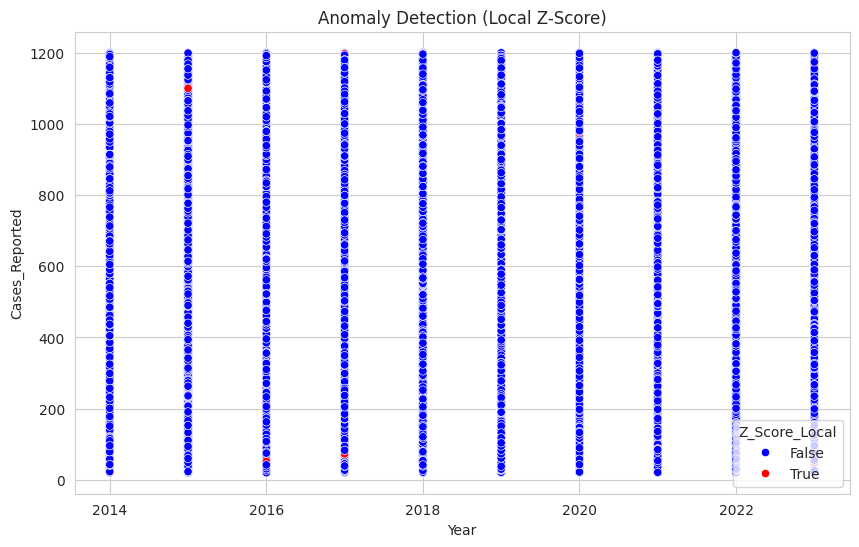

In [28]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x="Year",
    y="Cases_Reported",
    hue=df["Z_Score_Local"].abs() > 2,
    palette={True: "red", False: "blue"}
)

plt.title("Anomaly Detection (Local Z-Score)")
plt.show()

## Anomaly Detection

Instead of computing a global Z-score, anomalies were detected within each 
District–Crime category.

This approach identifies statistically unusual spikes relative to historical 
patterns within the same district.

Such localized anomaly detection is more meaningful for crime monitoring 
and policy intervention.

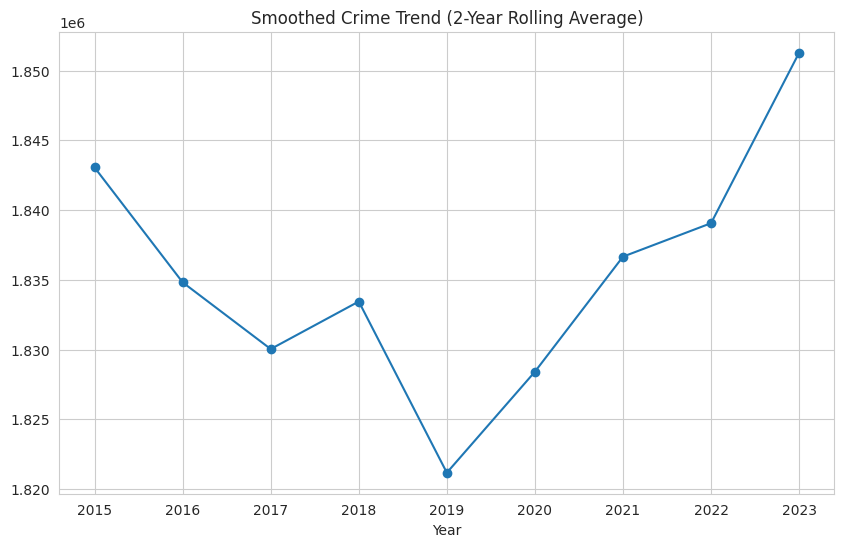

In [29]:
trend = df.groupby("Year")["Cases_Reported"].sum().rolling(2).mean()

trend.plot(marker="o")
plt.title("Smoothed Crime Trend (2-Year Rolling Average)")
plt.show()

## Advanced Findings

- Time-based validation gives more realistic performance.
- Crime trends show structural variation over years.
- Some districts exhibit statistically significant anomalies.
- Forecasting suggests moderate growth/stabilization patterns.

This notebook demonstrates:
- Feature engineering
- Time-aware modeling
- Forecasting
- Diagnostic evaluation
- Anomaly detection